#Thompson Sampling Implemantation

*   Goal is to find the best performing advertisement as quickly as possible
while running it online [Value of 'N' can be changed to verify the output]
*  Dataset is used to simulate the best performing advertisement.
*   Every Row is a round that is associated with a user.
*   there are 10 columns denoting 10 different advertisements
*  Each  column contains the reward that is obtained  when the ad is selected

*  Each round , we go through all the advertisements and  create a distribution for each advertisement based on its previous rewards colected [0 or 1].
We then  chose a random number from within these distribution

*   The advertisement with the highest random value  is selected for that round.
* The algorithm is run for different samplesize to find out how fast it is able detect the one that has higest reward








#Author- Yashas Samaga

###imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import random
import numpy as np


### Datasets

In [2]:
df = pd.read_csv('Ads_CTR_Optimisation.csv')
print(df)
print(df.shape)
# 1- advertisement is clicked by user
#  0 - advertisement is not clicked by user

      Ad 1  Ad 2  Ad 3  Ad 4  Ad 5  Ad 6  Ad 7  Ad 8  Ad 9  Ad 10
0        1     0     0     0     1     0     0     0     1      0
1        0     0     0     0     0     0     0     0     1      0
2        0     0     0     0     0     0     0     0     0      0
3        0     1     0     0     0     0     0     1     0      0
4        0     0     0     0     0     0     0     0     0      0
...    ...   ...   ...   ...   ...   ...   ...   ...   ...    ...
9995     0     0     1     0     0     0     0     1     0      0
9996     0     0     0     0     0     0     0     0     0      0
9997     0     0     0     0     0     0     0     0     0      0
9998     1     0     0     0     0     0     0     1     0      0
9999     0     1     0     0     0     0     0     0     0      0

[10000 rows x 10 columns]
(10000, 10)


###Implementing Thompson Sampling

In [3]:

#  Numbers of advertisement
d= len(df.iloc[0,:].values)
print(d)

10


In [4]:
import matplotlib.pyplot as plt

def plotGraph(N,ads_selected):
  bins = range(0, 10)  # 0–11 edges
  plt.hist(ads_selected)
  plt.xticks(range(0, 10))  # show 0 to 10 on x-axis
  plt.xlabel("advertisement")
  plt.ylabel("Frequency (Count)")
  plt.title(f"Histogram of advertisement vs Frequency for Sample Size {N}")

  plt.show()

* Step 1. At each round n, we consider two numbers for each ad i:
• numbers_of_Rewards_1 - the number of times the ad i got reward 1 up to round n,
• numbers_of_Rewards_0 - the number of times the ad i got reward O up to round n.

* Step 2. For each ad i, we take a random draw from the distribution below:
0(n) = B(N; (n) + 1, N, (n) + 1)
* Step 3. We select the ad that has the highest 0(n).

### Implementation of Beta probability distribution
* np.random.beta(alpha, beta)
* The parameters alpha and beta define the Beta probability distribution (PDF), and NumPy generates a random sample from that distribution.

* Logic
NumPy:

* * Uses the PDF defined by (α,β).
* * Randomly samples an x according to that PDF.
* * Returns a value between 0 and 1.

In [5]:
print(random.betavariate(5, 2))
print(np.random.beta(5, 2))
print(np.argmax([10000,100,3,4000000,5]))

0.5746329593631542
0.6293312253775479
3


In [6]:
def findBestPerformingAdvertisement(N):
  # reward count for adds with reward -1
  numbers_of_Rewards_1= [0 for i in range(0,10)]

  #   # reward count for adds with reward -0
  numbers_of_Rewards_0= [0 for i in range(0,10)]

  ads_selected= []

  for n in  range(0,N):
    ad_selected_per_round=0
    #  traversing through each add to build the samples array that consists
    #  of random points in each Adds Distribution
    samples = []
    for  i in range(0,d):
      #  collecting sucess and failures count  for each adds upto current round
      #  and chosing a random number from the beta distriubution
      alpha=numbers_of_Rewards_1[i] +1
      beta=numbers_of_Rewards_0[i] +1
      samples.append(np.random.beta(alpha, beta))


    ad_selected_per_round = np.argmax(samples)


    # 'ad_selected_per_round' is the add selected in round 'n'
    ads_selected.append(ad_selected_per_round)
    reward = int(df.iloc[n,ad_selected_per_round])
    if(reward ==1):
      numbers_of_Rewards_1[ad_selected_per_round]=numbers_of_Rewards_1[ad_selected_per_round]+1
    else:
      numbers_of_Rewards_0[ad_selected_per_round]=numbers_of_Rewards_0[ad_selected_per_round]+1


  plotGraph(N,ads_selected)



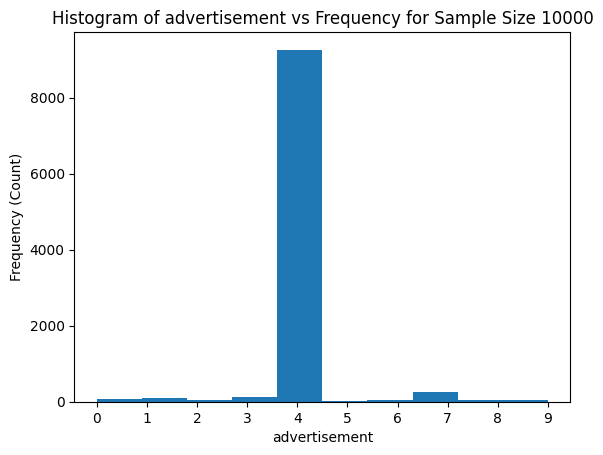

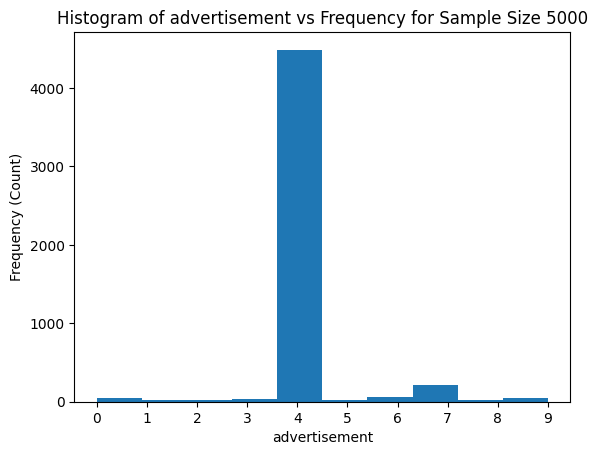

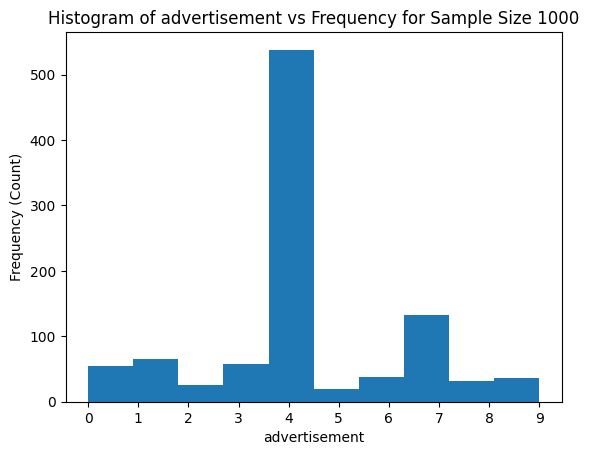

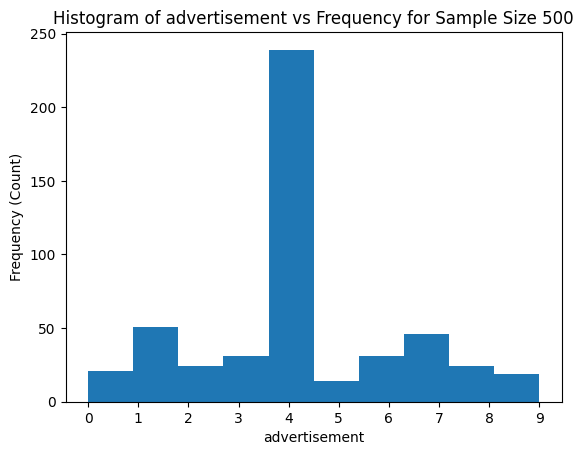

In [7]:
for sampleSize in [len(df),int(len(df)/2), int(len(df)/10), int(len(df)/20)]:
  findBestPerformingAdvertisement(sampleSize)

### conclusion



*   with N= 10000 , best performing advertisement = add Number 4
*    with N= 5000 , best performing advertisement = add Number 4
*  with N= 1000, best performing advertisement = add Number 4
*   with N = 500 ,best performing advertisement = add Number 4

This performs better than UCB as it was able to identify the best performing advertisement sooner than UCB



